In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7f2b6bac9a90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f2b6baca7b0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## This agentic pattern is based on orchestrator-worker workflow. Here, we have one orchestrator node which, breaks a task into multiple subtask, and then passes it to worker node. The worker node can create multiple worker nodes in parallel to complete the task. We can also create one collector node, which will collect all the responses from worker nodes and summarize them into one summary and show the output.

## **Pydantic LLM Schema**

In [7]:
from pydantic import BaseModel, Field
from typing import TypedDict


class llm_schema(BaseModel):
    # Groq may sometimes return a single string even when we ask for a list.
    task: list[str] | str = Field(description="Task(s) to be performed by worker")


llm_with_schema = llm.with_structured_output(llm_schema)

result = llm_with_schema.invoke(
    "Break this goal into 5 short actionable tasks and return `task` as an array: "
    "How to become a data scientist in 2026"
)

result


llm_schema(task=['Learn Python and R programming', 'Study statistics and data analysis', 'Familiarize yourself with machine learning algorithms', 'Practice with real-world datasets and projects', 'Pursue a certification in data science'])

## Graph schema

In [8]:
class GraphSchema(TypedDict):
    query:str
    task:list[str]
    result:list[str]
    summary:str

## creating orchestrator node

In [9]:
from langchain_core.prompts import ChatPromptTemplate


def orchestrator_node(state: GraphSchema) -> GraphSchema:
    user_query = state["query"]

    # Build a chat prompt (system + user) and request an array output.
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful assistant that breaks a user query into a list of actionable tasks.",
            ),
            (
                "user",
                "{user_query}\n\nGenerate one prompt per task for the worker node. Return `task` as an array.",
            ),
        ]
    )

    chain = prompt | llm_with_schema
    response = chain.invoke({"user_query": user_query})

    # llm_schema has `task`; normalize in case model returns a single string.
    tasks = response.task if isinstance(response.task, list) else [response.task]
    state["task"] = tasks

    return state




## worker node

In [10]:
def execute(query:str):

    response = llm.invoke(f"Execute this task: {query}")
    return response.content

## Let's create dynamic worker nodes with concurrent execution

In [11]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state:GraphSchema)->GraphSchema:

    tasks = state["task"]
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        results_futures = executor.map(execute, tasks)

        for result in results_futures:
            results.append(result)

    state["result"] = results

    return state

## collector node

In [12]:
def collector_node(state: GraphSchema) -> GraphSchema:
    results = state["result"]

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes worker node outputs."),
            (
                "user",
                "Here are the results from worker nodes:\n{results}\n\nSummarize them concisely.",
            ),
        ]
    )

    chain = prompt | llm
    response = chain.invoke({"results": "\n\n".join(results)})

    state["summary"] = response.content

    return state


## create graph and Execute

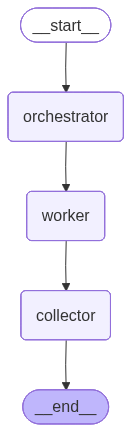

In [14]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(GraphSchema)

graph.add_node("orchestrator", orchestrator_node)
graph.add_node("worker", worker_node)
graph.add_node("collector", collector_node)

graph.add_edge(START, "orchestrator")
graph.add_edge("orchestrator", "worker")
graph.add_edge("worker", "collector")
graph.add_edge("collector", END)

orchestrator_graph = graph.compile()




from IPython.display import Image, display

Image(orchestrator_graph.get_graph().draw_mermaid_png())



In [16]:
orchestrator_graph.invoke(
    {
        "query": "Write an article for me in less than 50 words about the geopolitical relations of India. Further this main article would get converted into an instagram post, then to linkedin post and then to twitter(X) post. So make sure to change the wordings accordingly.",

    }
)

TypeError: expected str, got list